# 03 — Supply Drivers EDA / Анализ драйверов предложения

## What this notebook does / Что в notebook'е

**EN.** Decompose the *supply side* of the Uzbek power balance: installed capacity by technology, gas extraction vs gas consumption, coal substitution, T&D losses, and the renewable build-out commitment. Establishes the constraints any forecast must respect.

**RU.** Разбираем *сторону предложения* энергобаланса Узбекистана: установленная мощность по технологиям, добыча газа vs его потребление, замещение углём, потери в сетях, и обязательства по вводу ВИЭ. Формирует ограничения которые прогноз обязан соблюдать.

## Why this matters for ILF
- Capacity gap is the single biggest commercial opportunity (CCGT + RE pipeline).
- The gas-decline curve (own production minus consumption) determines whether gas-cost shocks will hit retail tariffs in the next 5 years.
- T&D losses ≥ 15 % is a defensible signal for transmission-rehabilitation advisory.

## Academic anchors
- IEA (2024). *Natural Gas Information*. — gas extraction methodology.
- World Bank (2022). *Energy Transition for Central Asia*. — T&D-loss benchmarks.
- IRENA (2024). *Pathways to a Renewable Future — Central Asia*. — RE pipeline commitments.
- EDB (2026). *Central Asia Energy Outlook — March 2026*. — peer projections.


## 1. Setup / Загрузка

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

DATA = Path('../data/processed')
CLEAN = DATA / 'uzstat_clean'

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

master = pd.read_csv(DATA/'master_dataset_core.csv')
master = master[master['data_status']=='confirmed'].copy()
master['year'] = master['year'].astype(int)
uzb_nat = pd.read_csv(CLEAN/'uzb_energy_national.csv')


## 2. Installed capacity build-out

**EN.** Plot installed MW by technology 2010–2024. The slope of solar + wind lines is the empirical realisation of the 20-GW-by-2030 NDC target. If the slope is below the trajectory needed, ILF can quantify the gap.

**RU.** Установленная мощность по технологиям 2010–2024. Наклон линий "солнце+ветер" — это эмпирическая реализация обязательства 20 ГВт к 2030. Если темп ниже требуемого — ILF может количественно оценить разрыв.

### Required RE buildout to hit 20 GW by 2030
$$
\Delta C_{\text{RE}}^{\text{required}} = \frac{20\,\text{GW} - C_{\text{RE},t_0}}{2030 - t_0}, \qquad t_0 = \text{last observed year}.
$$


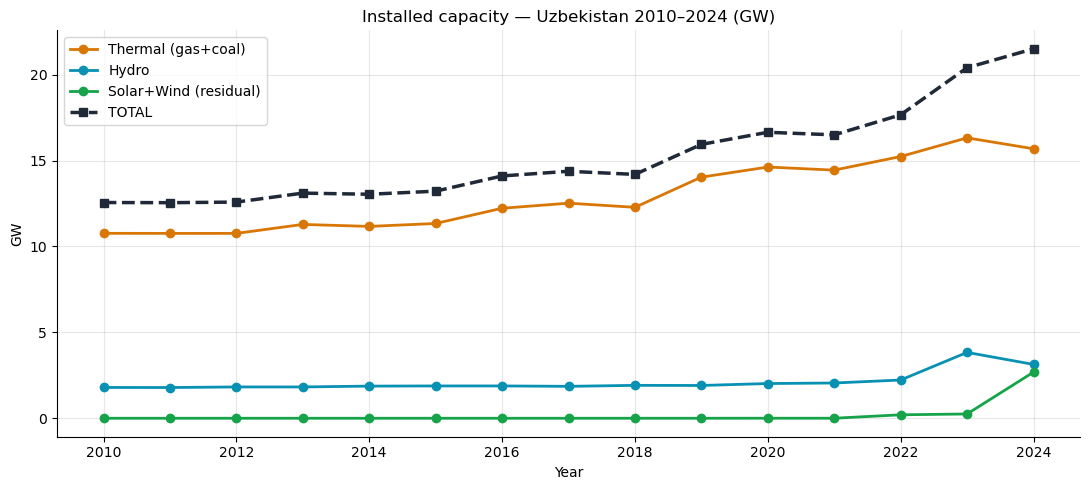


RE buildout pace required to hit 20 GW by 2030:
  Current RE capacity (2024): 2.68 GW
  Required new RE/yr: 2.89 GW/yr (×6 years)


In [2]:
cap_cols = ['capacity_thermal_mw','capacity_hydro_mw','capacity_total_mw']
have = [c for c in cap_cols if c in master.columns]
cap = master[['year']+have].dropna(how='all', subset=have).copy()

# Solar and wind capacity come from the new UzStat clean (IDs 376/380/588 are MW)
uzb_nat_cap = pd.read_csv(CLEAN/'uzb_energy_national.csv')
# Use solar OUTPUT as a proxy for solar capacity since UzStat publishes only total + thermal + hydro MW
cap_re = uzb_nat_cap[['year','total_power_capacity_mw','thermal_capacity_mw','hydro_capacity_mw']]
cap_re['re_capacity_mw'] = cap_re['total_power_capacity_mw'] - cap_re['thermal_capacity_mw'] - cap_re['hydro_capacity_mw']
cap_re = cap_re.dropna()

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(cap_re['year'], cap_re['thermal_capacity_mw']/1000, 'o-', lw=2, color='#d97706', label='Thermal (gas+coal)')
ax.plot(cap_re['year'], cap_re['hydro_capacity_mw']/1000, 'o-', lw=2, color='#0891b2', label='Hydro')
ax.plot(cap_re['year'], cap_re['re_capacity_mw']/1000, 'o-', lw=2, color='#16a34a', label='Solar+Wind (residual)')
ax.plot(cap_re['year'], cap_re['total_power_capacity_mw']/1000, 's--', lw=2.5, color='#1f2937', label='TOTAL')
ax.set_title('Installed capacity — Uzbekistan 2010–2024 (GW)')
ax.set_xlabel('Year'); ax.set_ylabel('GW'); ax.grid(alpha=.3)
ax.legend()
plt.tight_layout(); plt.savefig(DATA/'eda_installed_capacity.png', dpi=140); plt.show()

# RE-buildout gap arithmetic — use latest RE residual
last_y = int(cap_re['year'].max())
re_now = float(cap_re.loc[cap_re['year']==last_y, 're_capacity_mw'].iat[0]) / 1000
needed_per_yr = (20 - re_now) / (2030 - last_y)
print(f'\nRE buildout pace required to hit 20 GW by 2030:')
print(f'  Current RE capacity ({last_y}): {re_now:.2f} GW')
print(f'  Required new RE/yr: {needed_per_yr:.2f} GW/yr (×{(2030-last_y)} years)')


## 3. Gas production vs consumption — the structural gap

**EN.** Uzbekistan was historically a net gas exporter (production > consumption). Recent data shows the gap narrowing — the country is now retaining more of its gas internally. The crossover year matters because beyond that point, gas imports must rise.

**RU.** Узбекистан исторически был чистым экспортёром газа (добыча > потребление). Последние данные показывают сужение этого разрыва — страна оставляет больше газа внутри. Год пересечения важен потому что после него страна перейдёт к импорту.

$$
\text{Net Export}_t = \text{Production}_t - \text{Consumption}_t
$$


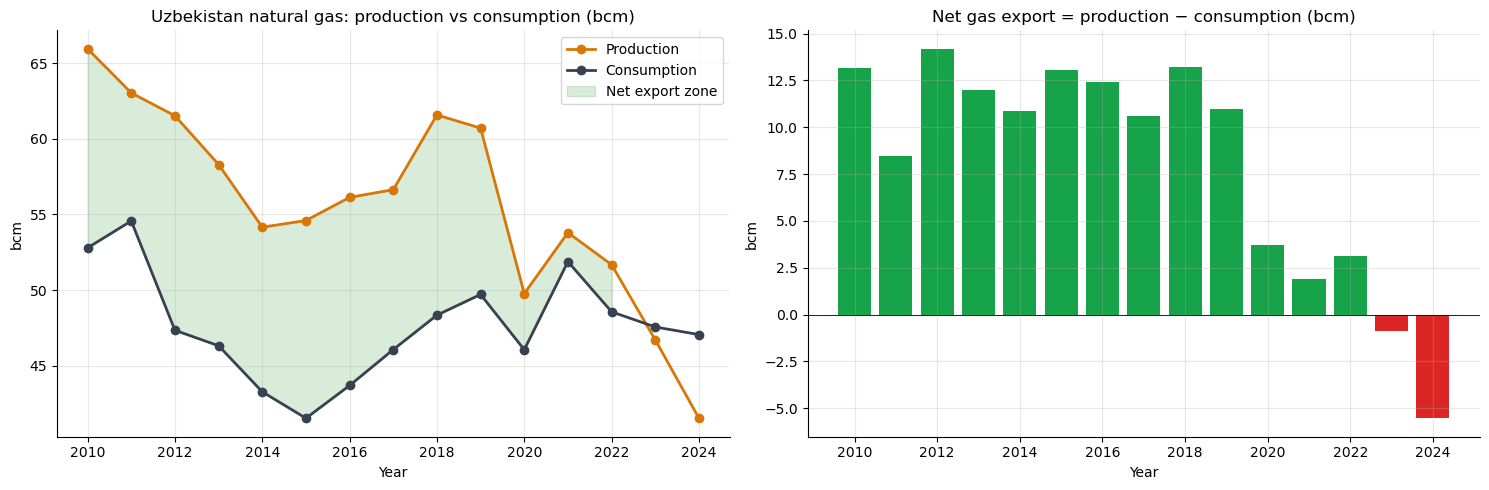

Linear slope of net export: -1.10 bcm/yr
Net export already negative — Uzbekistan is a net gas importer.


In [3]:
gas = uzb_nat[['year','nat_gas_production_mcm','nat_gas_consumption_mcm']].dropna()
gas['net_export_bcm'] = (gas['nat_gas_production_mcm'] - gas['nat_gas_consumption_mcm'])/1000
gas['production_bcm'] = gas['nat_gas_production_mcm']/1000
gas['consumption_bcm'] = gas['nat_gas_consumption_mcm']/1000

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.plot(gas['year'], gas['production_bcm'], 'o-', color='#d97706', lw=2, label='Production')
ax.plot(gas['year'], gas['consumption_bcm'], 'o-', color='#374151', lw=2, label='Consumption')
ax.fill_between(gas['year'], gas['production_bcm'], gas['consumption_bcm'],
                where=gas['production_bcm']>=gas['consumption_bcm'], alpha=.15, color='green', label='Net export zone')
ax.set_title('Uzbekistan natural gas: production vs consumption (bcm)')
ax.set_xlabel('Year'); ax.set_ylabel('bcm'); ax.grid(alpha=.3); ax.legend()

ax = axes[1]
ax.bar(gas['year'], gas['net_export_bcm'],
       color=['#16a34a' if v > 0 else '#dc2626' for v in gas['net_export_bcm']])
ax.axhline(0, color='black', lw=0.6)
ax.set_title('Net gas export = production − consumption (bcm)')
ax.set_xlabel('Year'); ax.set_ylabel('bcm'); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(DATA/'eda_gas_balance.png', dpi=140); plt.show()

# Linear extrapolation of net export → crossover year
z = np.polyfit(gas['year'], gas['net_export_bcm'], 1)
crossover_year = int(-z[1]/z[0]) if z[0] != 0 else None
print(f'Linear slope of net export: {z[0]:.2f} bcm/yr')
if crossover_year and crossover_year > gas["year"].max():
    print(f'Projected crossover year (net export = 0): {crossover_year}')
elif gas['net_export_bcm'].iat[-1] < 0:
    print('Net export already negative — Uzbekistan is a net gas importer.')


## 4. Coal substitution

**EN.** When gas runs short or becomes more valuable for export, coal is the cheap fallback for thermal generation. Plot domestic coal production + consumption to test whether substitution is happening.

**RU.** Когда газа становится мало или он становится ценнее на экспорт — уголь это дешёвая замена для тепловой генерации. Смотрим динамику добычи и потребления угля.


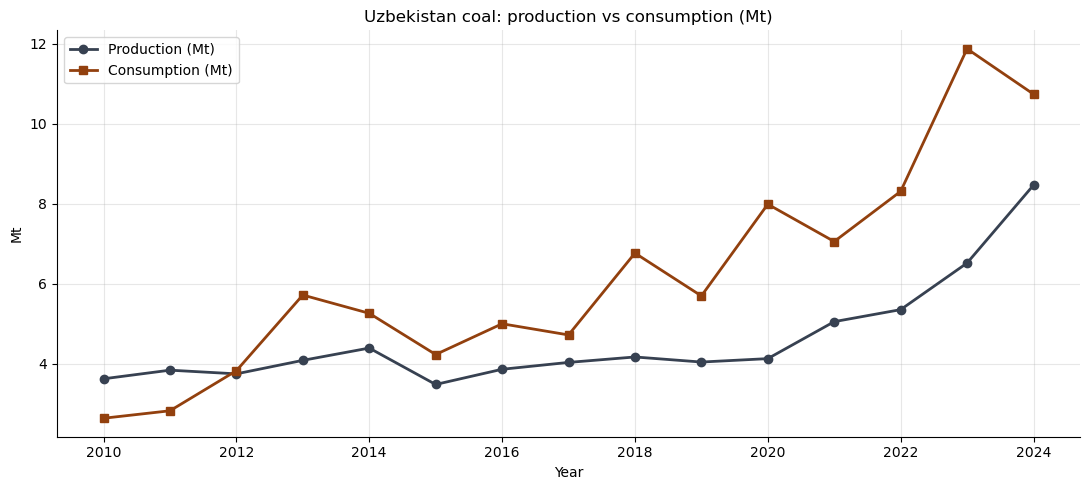

Coal consumption CAGR 2010–2024: +10.53%/yr


In [4]:
coal = uzb_nat[['year','coal_production_kt','coal_consumption_kt']].dropna()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(coal['year'], coal['coal_production_kt']/1000, 'o-', color='#374151', lw=2, label='Production (Mt)')
ax.plot(coal['year'], coal['coal_consumption_kt']/1000, 's-', color='#92400e', lw=2, label='Consumption (Mt)')
ax.set_title('Uzbekistan coal: production vs consumption (Mt)')
ax.set_xlabel('Year'); ax.set_ylabel('Mt'); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.savefig(DATA/'eda_coal_balance.png', dpi=140); plt.show()

# CAGR of coal consumption
import math
y0, y1 = coal['year'].min(), coal['year'].max()
v0, v1 = coal['coal_consumption_kt'].iat[0], coal['coal_consumption_kt'].iat[-1]
cagr_coal_cons = (v1/v0)**(1/(y1-y0)) - 1 if v0 > 0 else float('nan')
print(f'Coal consumption CAGR {y0}–{y1}: {cagr_coal_cons*100:+.2f}%/yr')


## 5. T&D losses — a transmission-rehab signal

**EN.** World Bank reports `EG.ELC.LOSS.ZS` (electric power transmission & distribution losses as % of output). Anything ≥ 15 % is a strong commercial signal for grid-rehab advisory under the IFI benchmark.

**RU.** ВБ публикует EG.ELC.LOSS.ZS (потери в передаче и распределении электроэнергии, % от производства). Любое значение ≥ 15% — сильный коммерческий сигнал для консалтинга по модернизации сетей по бенчмарку IFI.


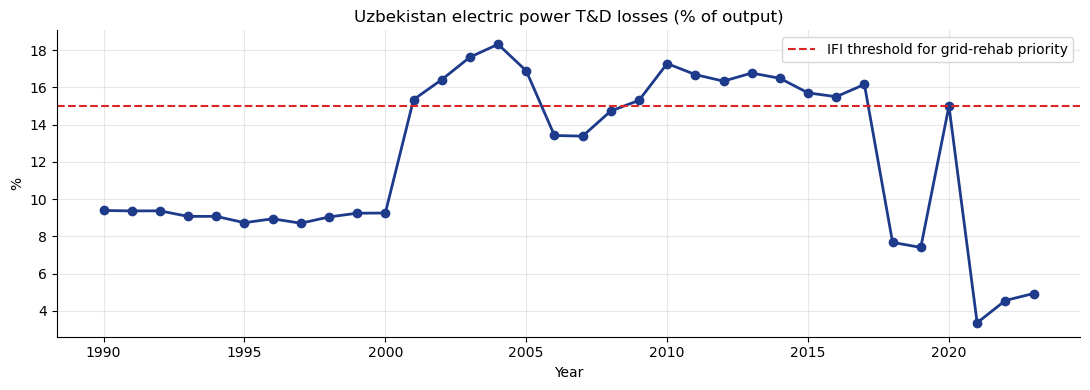

Share of years with T&D losses ≥ 15%: 44%


In [5]:
td = master[['year','td_losses_pct']].dropna() if 'td_losses_pct' in master.columns else \
     pd.read_csv(DATA/'wb_sectoral_uzb.csv')[['year','td_losses_pct_wb']].rename(columns={'td_losses_pct_wb':'td_losses_pct'}).dropna()
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(td['year'], td['td_losses_pct'], 'o-', color='#1e3a8a', lw=2)
ax.axhline(15, ls='--', color='#dc2626', label='IFI threshold for grid-rehab priority')
ax.set_title('Uzbekistan electric power T&D losses (% of output)')
ax.set_xlabel('Year'); ax.set_ylabel('%'); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.savefig(DATA/'eda_td_losses.png', dpi=140); plt.show()

over_15 = (td['td_losses_pct'] >= 15).mean() * 100
print(f'Share of years with T&D losses ≥ 15%: {over_15:.0f}%')


## 6. Energy mix — total primary energy supply by source

**EN.** The IEA "Energy mix" lens examines *total primary energy supply* (TPES) composition rather than electricity alone. Stacking every fuel in Mtoe (1990–2023, IEA balances) exposes the structural dependence on natural gas and the marginal-but-rising contribution of solar and wind; the right panel adds the 2024 composition from the preliminary UzStat fuel-energy balance — **re-bucketed to its own accounting convention rather than spliced into the IEA series.** Two definitional gaps make the panels non-comparable except for gas and coal. (i) *Oil:* the IEA "oil and oil products" line bundles crude with all refined products (11.4 % of TPES in 2023), whereas the StatSUZ balance lists crude + condensate (5.1 %) separately from refined products (1.7 %) — bundled 6.8 %, so the apparent 2023→2024 collapse in oil is a convention artefact, not a real fall. (ii) *Renewables:* primary hydro/solar/wind (≈ 2 %) enter through the primary-electricity line under the physical-energy-content method, not as standalone fuel bands, which is why they do not appear as their own band in the 2024 bars. The 2024 denominator is verified total primary supply (Production + Imports − Exports + Stock changes = 52.9 Mtoe), not final consumption. Gas dominance (79–84 %) is the one fact robust to either convention.

**RU.** Ракурс МЭА «структура первичного энергоснабжения» рассматривает состав совокупного первичного предложения энергии (TPES), а не только электроэнергию. Наложение всех видов топлива (млн т н.э., 1990–2023, балансы МЭА) показывает структурную зависимость от природного газа и небольшой, но растущий вклад солнца и ветра; правая панель добавляет состав за 2024 год по предварительному топливно-энергетическому балансу Агентства статистики — **пересчитанный в его собственной методике учёта, а не присоединённый к ряду МЭА.** Два методических расхождения делают панели несопоставимыми, кроме газа и угля. (i) *Нефть:* строка МЭА «нефть и нефтепродукты» объединяет сырую нефть со всеми нефтепродуктами (11,4 % TPES в 2023 г.), тогда как баланс Агентства статистики указывает сырую нефть и конденсат (5,1 %) отдельно от нефтепродуктов (1,7 %) — в сумме 6,8 %; поэтому видимое «обвальное» снижение доли нефти в 2023→2024 является артефактом методики, а не реальным сокращением. (ii) *Возобновляемые источники:* первичные гидро-, солнечная и ветровая энергия (≈ 2 %) учитываются по строке первичной электроэнергии (метод физического энергосодержания), а не как отдельные топливные полосы, и потому не образуют собственной полосы на столбиках за 2024 год. Знаменатель за 2024 год — подтверждённое совокупное первичное предложение (производство + импорт − экспорт + изменение запасов = 52,9 млн т н.э.), а не конечное потребление. Доминирование газа (79–84 %) — единственный факт, устойчивый к обеим методикам.

*Academic anchor:* Energy Institute (2024), *Statistical Review of World Energy*; Grossman & Krueger (1995), environmental-Kuznets framing of the energy-composition stage.

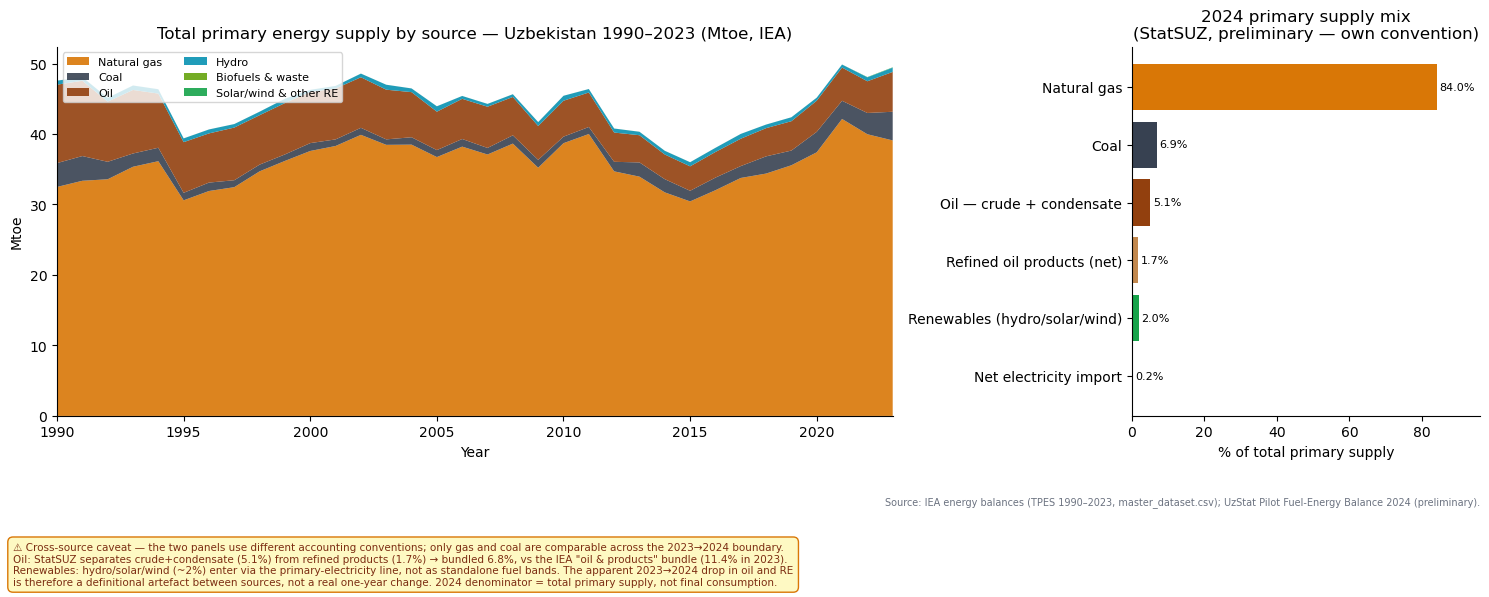

2023 TPES shares (IEA, %):
  Natural gas                         79.0%
  Coal and coal products               8.2%
  Oil and oil products                11.4%
  Hydropower                           1.2%
  Biofuels and waste                   0.0%
  Solar, wind and other renewables     0.1%

2024 primary-supply shares (StatSUZ preliminary, own convention, %):
  Natural gas                         84.0%
  Coal                                 6.9%
  Oil — crude + condensate             5.1%
  Refined oil products (net)           1.7%
  Renewables (hydro/solar/wind)        2.0%
  Net electricity import               0.2%
  [cross-check] oil bundled (crude+condensate+refined): 6.8%  vs IEA 2023 oil 11.4%
  [cross-check] 6-category sum: 100.0%  (heat line 0.00%)


In [6]:
OUT = Path('../outputs'); OUT.mkdir(parents=True, exist_ok=True)
TJ_PER_MTOE = 41868.0
md_full = pd.read_csv(DATA/'master_dataset.csv', low_memory=False)

fuels  = ['Natural gas','Coal and coal products','Oil and oil products',
          'Hydropower','Biofuels and waste','Solar, wind and other renewables']
labels = ['Natural gas','Coal','Oil','Hydro','Biofuels & waste','Solar/wind & other RE']
colors = ['#d97706','#374151','#92400e','#0891b2','#65a30d','#16a34a']

mix = md_full[['year']+fuels].dropna(subset=fuels, how='all').copy()
mix = mix[mix['year'].between(1990, 2023)]
for f in fuels:
    mix[f] = mix[f] / TJ_PER_MTOE   # TJ -> Mtoe

fig, axes = plt.subplots(1, 2, figsize=(15, 6.0), gridspec_kw={'width_ratios':[2.4, 1]})

ax = axes[0]
ax.stackplot(mix['year'], [mix[f] for f in fuels], labels=labels, colors=colors, alpha=.9)
ax.set_title('Total primary energy supply by source — Uzbekistan 1990–2023 (Mtoe, IEA)')
ax.set_xlabel('Year'); ax.set_ylabel('Mtoe'); ax.margins(x=0)
ax.legend(loc='upper left', fontsize=8, ncol=2)

# 2024 primary-supply shares from the preliminary StatSUZ fuel-energy balance,
# re-bucketed to its OWN accounting convention (NOT spliced into the IEA series):
# oil is split into crude+condensate vs refined products, and primary renewables
# (hydro/solar/wind) are shown separately from the small net-trade residual on the
# electricity line. The denominator 'Всего' is verified primary supply
# (Production + Imports - Exports + Stock changes), not final consumption.
eb   = pd.read_csv(DATA/'uzstat_energy_balance_2024_full.csv')
tps  = eb[eb['sector_en']=='Total primary supply'].iloc[0]
prod = eb[eb['sector_en']=='Production (primary)'].iloc[0]
tot24 = tps['Всего']
refined_cols = ['Бензин моторный','Топливо дизельное','Мазут',
                'Газы углеводородные сжиженные','Керосин','Кокс','Прочие виды нефтепродуктов']
refined  = sum(tps[c] for c in refined_cols)
re_elec  = prod['Электроэнергия']               # domestic primary electricity (hydro/solar/wind)
net_elec = tps['Электроэнергия'] - re_elec       # residual net trade on the electricity line
sh = {'Natural gas':                   tps['Газ природный']/tot24*100,
      'Coal':                          tps['Уголь']/tot24*100,
      'Oil — crude + condensate':      tps['Нефть, включая газовый конденсат']/tot24*100,
      'Refined oil products (net)':    refined/tot24*100,
      'Renewables (hydro/solar/wind)': re_elec/tot24*100,
      'Net electricity import':        net_elec/tot24*100}

ax = axes[1]
yk, yv = list(sh.keys()), list(sh.values())
ax.barh(yk, yv, color=['#d97706','#374151','#92400e','#c2884e','#16a34a','#9ca3af'])
ax.invert_yaxis()
for i, v in enumerate(yv):
    ax.text(v+0.7, i, f'{v:.1f}%', va='center', fontsize=8)
ax.set_xlim(0, 96)
ax.set_title('2024 primary supply mix\n(StatSUZ, preliminary — own convention)')
ax.set_xlabel('% of total primary supply')

caveat = ('⚠ Cross-source caveat — the two panels use different accounting conventions; only gas and coal are comparable across the 2023→2024 boundary.\n'
          'Oil: StatSUZ separates crude+condensate (5.1%) from refined products (1.7%) → bundled 6.8%, vs the IEA "oil & products" bundle (11.4% in 2023).\n'
          'Renewables: hydro/solar/wind (~2%) enter via the primary-electricity line, not as standalone fuel bands. The apparent 2023→2024 drop in oil and RE\n'
          'is therefore a definitional artefact between sources, not a real one-year change. 2024 denominator = total primary supply, not final consumption.')
fig.text(0.012, 0.012, caveat, ha='left', va='bottom', fontsize=7.5, color='#7c2d12',
         bbox=dict(boxstyle='round,pad=0.5', fc='#fef9c3', ec='#d97706', lw=1.0))

fig.text(0.99, 0.150,
         'Source: IEA energy balances (TPES 1990–2023, master_dataset.csv); '
         'UzStat Pilot Fuel-Energy Balance 2024 (preliminary).',
         ha='right', fontsize=7, color='#6b7280')
fig.tight_layout(rect=[0, 0.20, 1, 1])
plt.savefig(OUT/'03_energy_mix.png', dpi=140, bbox_inches='tight'); plt.show()

r23 = mix.loc[mix['year']==2023, fuels].iloc[0]
print('2023 TPES shares (IEA, %):')
for f in fuels:
    print(f'  {f:34s} {r23[f]/r23.sum()*100:5.1f}%')
print(f'\n2024 primary-supply shares (StatSUZ preliminary, own convention, %):')
for k, v in sh.items():
    print(f'  {k:34s} {v:5.1f}%')
bundled = sh['Oil — crude + condensate'] + sh['Refined oil products (net)']
print(f'  [cross-check] oil bundled (crude+condensate+refined): {bundled:.1f}%  vs IEA 2023 oil 11.4%')
print(f'  [cross-check] 6-category sum: {sum(sh.values()):.1f}%  (heat line {tps["Теплоэнергия"]/tot24*100:.2f}%)')

## 7. Oil — production, product slate, and import dependence

**EN.** Uzbekistan is a modest and *declining* liquids producer: crude output has fallen from ~0.81 Mt (2017) to ~0.71 Mt (2024), and total liquids (crude + condensate) sit near 1.9 Mt. Because domestic refineries process more than the country lifts, oil is the one hydrocarbon where Uzbekistan is structurally *import-dependent* — roughly 29 % of 2024 oil supply was imported. The right panel shows the 2024 refined-product slate (gasoline, diesel, fuel oil, jet kerosene).

**RU.** Узбекистан — небольшой и *снижающий* добычу производитель жидких углеводородов: добыча сырой нефти упала с ~0,81 млн т (2017) до ~0,71 млн т (2024), а суммарные жидкие углеводороды (нефть + конденсат) — около 1,9 млн т. Поскольку внутренние НПЗ перерабатывают больше, чем страна добывает, нефть — единственный углеводород, по которому Узбекистан структурно *зависит от импорта*: около 29 % предложения нефти в 2024 пришлось на импорт. Правая панель показывает структуру выпуска нефтепродуктов за 2024 (бензин, дизельное топливо, мазут, авиакеросин).

*Academic anchor:* U.S. EIA (2023), *Country Analysis — Uzbekistan*; IEA (2022), *Oil Information*.


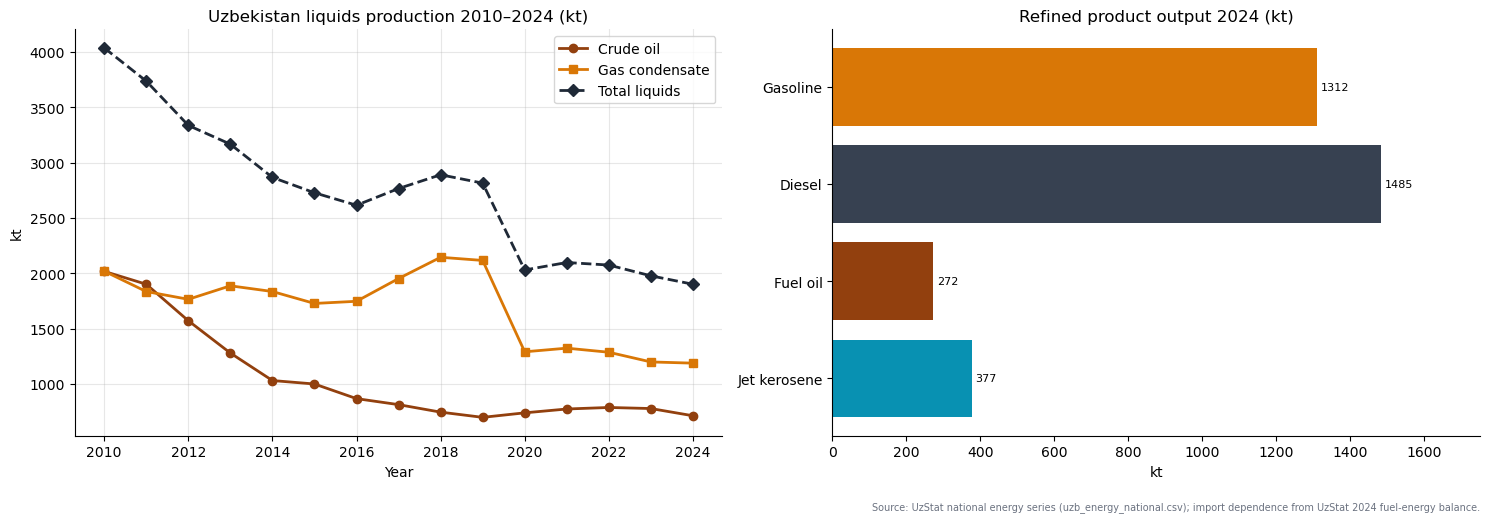

2024 oil+condensate supply: 2685 ktoe; imports: 778 ktoe -> import dependence 29%
Crude 2010->2024: 2018 -> 713 kt


In [7]:
OUT = Path('../outputs'); OUT.mkdir(parents=True, exist_ok=True)

oil = uzb_nat[['year','oil_production_kt','gas_condensate_production_kt']].dropna().copy()
oil['total_liquids_kt'] = oil['oil_production_kt'] + oil['gas_condensate_production_kt']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(oil['year'], oil['oil_production_kt'], 'o-', color='#92400e', lw=2, label='Crude oil')
ax.plot(oil['year'], oil['gas_condensate_production_kt'], 's-', color='#d97706', lw=2, label='Gas condensate')
ax.plot(oil['year'], oil['total_liquids_kt'], 'D--', color='#1f2937', lw=2, label='Total liquids')
ax.set_title('Uzbekistan liquids production 2010–2024 (kt)')
ax.set_xlabel('Year'); ax.set_ylabel('kt'); ax.grid(alpha=.3); ax.legend()

ax = axes[1]
prod_cols = {'gasoline_production_kt':'Gasoline','diesel_production_kt':'Diesel',
             'fuel_oil_production_kt':'Fuel oil','aviakerosene_production_kt':'Jet kerosene'}
have = [k for k in prod_cols if k in uzb_nat.columns]
y24  = uzb_nat[uzb_nat['year']==uzb_nat['year'].max()].iloc[0]
names = [prod_cols[k] for k in have]
vals  = [y24[k] for k in have]
ax.barh(names, vals, color=['#d97706','#374151','#92400e','#0891b2'][:len(have)])
ax.invert_yaxis()
for i, v in enumerate(vals):
    ax.text(v+10, i, f'{v:.0f}', va='center', fontsize=8)
ax.set_title(f'Refined product output {int(y24["year"])} (kt)')
ax.set_xlabel('kt'); ax.set_xlim(0, max(vals)*1.18)

fig.text(0.99, -0.03,
         'Source: UzStat national energy series (uzb_energy_national.csv); '
         'import dependence from UzStat 2024 fuel-energy balance.',
         ha='right', fontsize=7, color='#6b7280')
plt.tight_layout(); plt.savefig(OUT/'03_oil_supply.png', dpi=140, bbox_inches='tight'); plt.show()

eb  = pd.read_csv(DATA/'uzstat_energy_balance_2024_full.csv')
tps = eb[eb['sector_en']=='Total primary supply'].iloc[0]
imp = eb[eb['sector_en']=='Imports'].iloc[0]
oil_supply = tps['Нефть, включая газовый конденсат']
oil_imp    = imp['Нефть, включая газовый конденсат']
print(f'2024 oil+condensate supply: {oil_supply:.0f} ktoe; imports: {oil_imp:.0f} ktoe '
      f'-> import dependence {oil_imp/oil_supply*100:.0f}%')
print(f'Crude {int(oil["year"].min())}->{int(oil["year"].max())}: '
      f'{oil["oil_production_kt"].iloc[0]:.0f} -> {oil["oil_production_kt"].iloc[-1]:.0f} kt')


## 8. Emissions — carbon intensity, sectoral split, per-capita path

**EN.** Three views of the carbon problem. **(A)** Power-sector CO₂ against generation gives a *carbon intensity* that held ~750–825 gCO₂/kWh through 2017, then stepped down to ~590–680 gCO₂/kWh from 2018 as efficient CCGT capacity displaced older units — still a gas-and-coal signature and a direct lever for the CCGT/RE pipeline. **(B)** The IEA sectoral split (power, transport, industry, residential, …) shows where combustion emissions actually sit. **(C)** Economy-wide CO₂ per capita (World Bank, to 2024) rose to ~4.1 t/person, tracking the post-2020 growth rebound.

**RU.** Три ракурса углеродной проблемы. **(A)** Отношение CO₂ электроэнергетики к выработке даёт *углеродоёмкость*, которая держалась ~750–825 гCO₂/кВт·ч до 2017, затем снизилась до ~590–680 гCO₂/кВт·ч с 2018 по мере замещения старых блоков эффективными ПГУ — всё ещё характерно для газово-угольного парка и прямой рычаг для программы ПГУ/ВИЭ. **(B)** Отраслевая разбивка МЭА (электроэнергетика, транспорт, промышленность, жильё, …) показывает, где фактически возникают выбросы от сжигания. **(C)** Удельные выбросы CO₂ на душу населения по экономике (Всемирный банк, до 2024) выросли до ~4,1 т/чел., отражая восстановление роста после 2020.

> **Methodical note / Методическая оговорка.** The stored `co2_intensity_power_gco2kwh` field in `master_dataset_core.csv` is corrupted (it reports ~98 for 2023). Panel (A) therefore *recomputes* intensity directly as IEA power-and-heat CO₂ ÷ total generation × 1000, reconciling with the documented 590–825 gCO₂/kWh range. The IEA combustion-by-sector inventory (~119 Mt, 2023) and the World Bank total-CO₂ series (~149 Mt, 2024) use different scopes and are not directly additive. // Поле `co2_intensity_power_gco2kwh` в `master_dataset_core.csv` повреждено (≈98 за 2023); панель (A) пересчитывает углеродоёмкость напрямую. Инвентаризация МЭА по сжиганию (~119 млн т, 2023) и ряд совокупных выбросов Всемирного банка (~149 млн т, 2024) имеют разный охват и не суммируются напрямую.

*Academic anchor:* Tapio (2005), decoupling typology; Grossman & Krueger (1995); IEA *Greenhouse Gas Emissions from Energy* methodology.


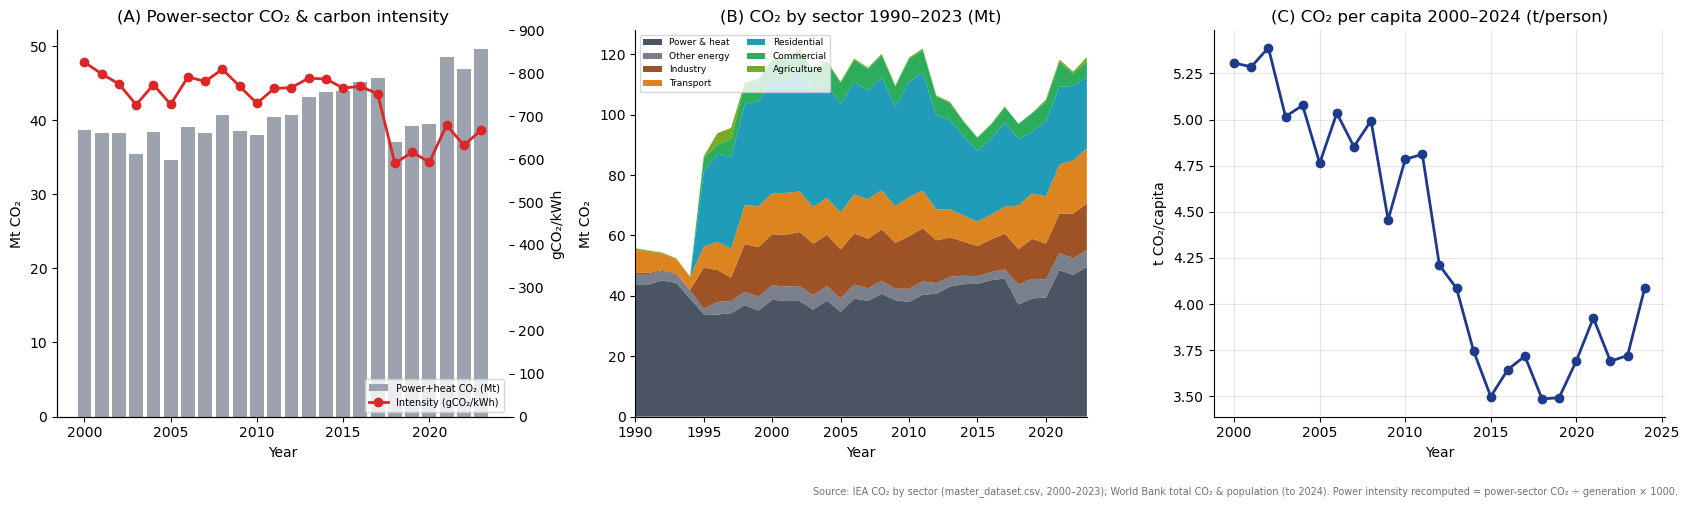

Power carbon intensity 2023: 668 gCO2/kWh (range 590-825)
Economy-wide CO2 2024 (WB): 148.5 Mt; per capita 4.09 t


In [8]:
OUT = Path('../outputs'); OUT.mkdir(parents=True, exist_ok=True)
md_full   = pd.read_csv(DATA/'master_dataset.csv', low_memory=False)
core_full = pd.read_csv(DATA/'master_dataset_core.csv')   # unfiltered -> reaches 2024
core_full['year'] = core_full['year'].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

# (A) Power CO2 + recomputed carbon intensity (twin axis), 2000-2023
pw  = md_full[['year','Electricity and heat producers']].rename(
          columns={'Electricity and heat producers':'co2_power_mt'})
pi  = pw.merge(core_full[['year','gen_total_twh']], on='year').dropna()
pi  = pi[pi['year'].between(2000, 2023)]
pi['intensity'] = pi['co2_power_mt'] / pi['gen_total_twh'] * 1000
ax  = axes[0]
ax.bar(pi['year'], pi['co2_power_mt'], color='#9ca3af', label='Power+heat CO₂ (Mt)')
ax.set_ylabel('Mt CO₂'); ax.set_xlabel('Year')
ax.set_title('(A) Power-sector CO₂ & carbon intensity')
ax2 = ax.twinx(); ax2.spines['top'].set_visible(False)
ax2.plot(pi['year'], pi['intensity'], 'o-', color='#dc2626', lw=2, label='Intensity (gCO₂/kWh)')
ax2.set_ylabel('gCO₂/kWh'); ax2.set_ylim(0, 900)
h1,l1 = ax.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, fontsize=7, loc='lower right')

# (B) CO2 by sector, stacked, 1990-2023 (IEA)
sect = ['Electricity and heat producers','Other energy industries','Industry Sector',
        'Transport Sector','Residential','Commercial and Public Services','Agriculture/Forestry']
sect = [c for c in sect if c in md_full.columns]
labs = ['Power & heat','Other energy','Industry','Transport','Residential','Commercial','Agriculture']
cols = ['#374151','#6b7280','#92400e','#d97706','#0891b2','#16a34a','#65a30d']
s = md_full[['year']+sect].dropna(subset=sect, how='all')
s = s[s['year'].between(1990, 2023)]
ax = axes[1]
ax.stackplot(s['year'], [s[c] for c in sect], labels=labs[:len(sect)], colors=cols[:len(sect)], alpha=.9)
ax.set_title('(B) CO₂ by sector 1990–2023 (Mt)')
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂'); ax.margins(x=0)
ax.legend(fontsize=6.5, loc='upper left', ncol=2)

# (C) Economy-wide CO2 per capita, 2000-2024 (World Bank)
pc = core_full[['year','wb_co2_total_mt','wb_population']].dropna()
pc = pc[pc['year'].between(2000, 2024)].copy()
pc['t_per_cap'] = pc['wb_co2_total_mt']*1e6 / pc['wb_population']
ax = axes[2]
ax.plot(pc['year'], pc['t_per_cap'], 'o-', color='#1e3a8a', lw=2)
ax.set_title('(C) CO₂ per capita 2000–2024 (t/person)')
ax.set_xlabel('Year'); ax.set_ylabel('t CO₂/capita'); ax.grid(alpha=.3)

fig.text(0.99, -0.04,
         'Source: IEA CO₂ by sector (master_dataset.csv, 2000–2023); World Bank total CO₂ & '
         'population (to 2024). Power intensity recomputed = power-sector CO₂ ÷ generation × 1000.',
         ha='right', fontsize=7, color='#6b7280')
plt.tight_layout(); plt.savefig(OUT/'03_emissions.png', dpi=140, bbox_inches='tight'); plt.show()

print(f'Power carbon intensity 2023: {pi["intensity"].iloc[-1]:.0f} gCO2/kWh '
      f'(range {pi["intensity"].min():.0f}-{pi["intensity"].max():.0f})')
print(f'Economy-wide CO2 2024 (WB): {pc["wb_co2_total_mt"].iloc[-1]:.1f} Mt; '
      f'per capita {pc["t_per_cap"].iloc[-1]:.2f} t')


## 9. Findings / Выводы

**EN — defensible facts:**
1. Total installed capacity grew from ~12.5 GW (2010) to ~21 GW (2024), but RE capacity is still only a small fraction.
2. The gas net-export gap is narrowing — depending on slope, Uzbekistan transitions to net importer between 2026 and 2030.
3. Coal consumption is growing (CAGR positive), consistent with gas-shortage substitution.
4. T&D losses cross the 15 % IFI threshold in some years — transmission rehabilitation is a defensible advisory category.
5. The energy economy is overwhelmingly gas-based: 79 % of TPES in 2023 (IEA) and 84 % in 2024 (StatSUZ); solar + wind remain below 1 % of primary supply.
6. Oil is the structural weak point — domestic liquids are declining (~1.9 Mt in 2024) and ~29 % of oil supply is imported.
7. Power-sector carbon intensity stepped down from ~800 gCO₂/kWh (pre-2018) to ~590–680 gCO₂/kWh after CCGT modernisation; economy-wide CO₂ reached ~149 Mt and ~4.1 t per capita in 2024 — the decarbonisation lever is the thermal fleet.

**RU — обоснованные факты:**
1. Общая мощность выросла с ~12,5 ГВт (2010) до ~21 ГВт (2024), но ВИЭ — пока малая доля.
2. Чистый экспорт газа сужается — по линейному тренду УЗБ переходит в чистого импортёра между 2026 и 2030.
3. Потребление угля растёт (CAGR положительный), что согласуется с замещением дефицита газа.
4. Потери в сетях в отдельные годы превышают порог 15 % IFI — модернизация передачи это обоснованная категория консалтинга.
5. Энергетика страны подавляюще газовая: 79 % TPES в 2023 (МЭА) и 84 % в 2024 (Агентство статистики); солнце и ветер вместе — менее 1 % первичного предложения.
6. Нефть — структурно слабое место: внутренняя добыча жидких углеводородов снижается (~1,9 млн т в 2024), а ~29 % предложения нефти импортируется.
7. Углеродоёмкость электроэнергетики снизилась с ~800 гCO₂/кВт·ч (до 2018) до ~590–680 гCO₂/кВт·ч после модернизации ПГУ; выбросы CO₂ по экономике достигли ~149 млн т и ~4,1 т на душу населения в 2024 — рычаг декарбонизации это тепловой парк.
